# ENSO RL — Analysis Notebook

All figures and tables for the paper. Run computation scripts first to generate `.npz`/`.csv` files, then use this notebook to produce publication-quality plots without recomputing.

**Computation scripts** (run from repo root):
```bash
# Unified inference (lift + seasonality raw data)
uv run scripts/analysis/inference.py               --model ensemble

# XAI methods (each independent)
uv run scripts/analysis/counterfactual_analysis.py --model ensemble
uv run scripts/analysis/shapley_analysis.py        --model ensemble
uv run scripts/analysis/interventional_xro.py      --model ensemble
uv run scripts/analysis/precursor_composite.py     --model ensemble
uv run scripts/analysis/mutual_information.py      --model ensemble
uv run scripts/analysis/integrated_gradients.py    --model ensemble
uv run scripts/analysis/gradient_sensitivity.py    --model ensemble
```

## Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.stats import spearmanr, ttest_1samp
from scipy.stats import t as t_dist

sys.path.insert(0, str(Path("..").resolve()))
from utils.enso_classifier import _find_continuous_runs

NAME = "model2"   # matches --model used when running computation scripts
BASE = Path("..") / "plots" / NAME

PHASES       = ["total", "el_nino", "la_nina"]
PHASE_LABELS = {"total": "Total MYE", "el_nino": "Multi-year El Niño", "la_nina": "Multi-year La Niña"}
PHASE_COLORS = {"total": "#4878CF", "el_nino": "#D65F5F", "la_nina": "#5CB85C"}
XRO_MODES    = ["WWV", "NPMM", "SPMM", "IOB", "IOD", "SIOD", "TNA", "ATL3", "SASD"]
SPINUP       = 12  # months skipped for seasonality binning (fixed by XRO env)

PHASE_MASKS = {
    'total':   lambda l: l >= 3,
    'el_nino': lambda l: l == 3,
    'la_nina': lambda l: l == 4,
}

def _zscore(x):
    x = np.asarray(x, float)
    sd = x.std()
    return (x - x.mean()) / sd if sd > 1e-12 else x - x.mean()

def _sig_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

def _add_sig_labels(ax, x_positions, values, pvals, offset_frac=0.04):
    """Annotate bar chart with significance stars."""
    ylim = ax.get_ylim()
    offset = (ylim[1] - ylim[0]) * offset_frac
    for xi, val, p in zip(x_positions, values, pvals):
        star = _sig_stars(p)
        y = val + offset if val >= 0 else val - offset
        va = "bottom" if val >= 0 else "top"
        ax.text(xi, y, star, ha="center", va=va, fontsize=9, fontweight="bold")

def _mean_ci(arr):
    """Mean and 95% CI (t-distribution) across seeds."""
    n = len(arr)
    ci = t_dist.ppf(0.975, df=n-1) * arr.std(ddof=1) / np.sqrt(n)
    return arr.mean(), ci

def _load_npz(path):
    """Load npz and return as a dict-like NpzFile (supports 'key in d.files')."""
    return np.load(path, allow_pickle=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print(f"BASE = {BASE.resolve()}")

BASE = /Users/ayman/research/enso-rl/plots/model2


---
## 0. Trajectory Diagnostics

Single-trajectory and distribution diagnostics ported from the retired `evaluate.py`:
Nino3.4 with month-by-month phase classification, the styled ENSO table, raw
state/action time series, and action/state distributions resolved by ENSO phase.
All data comes from the same `inference.npz` raw rollouts used in the rest of the notebook.

In [20]:
# Raw rollouts (same file the lift section loads later)
d_inf = _load_npz(BASE / "inference.npz")
THRESHOLD = 0.5   # ENSO event threshold (matches EnvConfig.threshold)

# Int8 MYE-label encoding produced by inference.py
LABEL_NAMES = {0: 'Neutral',
               1: 'Single-year El Nino', 2: 'Single-year La Nina',
               3: 'Multi-year El Nino',  4: 'Multi-year La Nina'}

traj_var_names    = list(d_inf['var_names'])     # ['Nino34', 'WWV', ...] (10)
traj_action_names = list(d_inf['action_names'])  # forcing modes (9)

n_seeds, n_rollouts = d_inf['agent_obs'].shape[:2]

# ============================================================================
# >>> CHANGE THESE to pick which ensemble rollout plots 0a-0d show <<<
SEED_IDX    = 4   # ensemble member       (0 .. n_seeds-1)
ROLLOUT_IDX = 0   # rollout of that member (0 .. n_rollouts-1)
# ============================================================================

assert 0 <= SEED_IDX < n_seeds,       f"SEED_IDX must be in 0..{n_seeds-1}"
assert 0 <= ROLLOUT_IDX < n_rollouts, f"ROLLOUT_IDX must be in 0..{n_rollouts-1}"

states_traj  = d_inf['agent_obs'][SEED_IDX, ROLLOUT_IDX]        # [T, 10]
actions_traj = d_inf['agent_actions'][SEED_IDX, ROLLOUT_IDX]    # [T, 9]
labels_traj  = d_inf['agent_mye_label'][SEED_IDX, ROLLOUT_IDX]  # [T] int8
enso_traj    = states_traj[:, 0]                               # Nino3.4 column
T_traj       = len(enso_traj)

print(f"Ensemble: {n_seeds} seeds x {n_rollouts} rollouts   "
      f"(seed_idx 0..{n_seeds-1}, rollout_idx 0..{n_rollouts-1})")
print(f"Showing  : seed_idx={SEED_IDX}, rollout_idx={ROLLOUT_IDX}, T={T_traj} months")
print("Phase month counts:",
      {LABEL_NAMES[k]: int((labels_traj == k).sum()) for k in LABEL_NAMES})

Ensemble: 5 seeds x 1 rollouts   (seed_idx 0..4, rollout_idx 0..0)
Showing  : seed_idx=4, rollout_idx=0, T=1200 months
Phase month counts: {'Neutral': 209, 'Single-year El Nino': 11, 'Single-year La Nina': 0, 'Multi-year El Nino': 394, 'Multi-year La Nina': 586}


### 0a. Nino3.4 with per-mo phase classification (NO Ensemble)

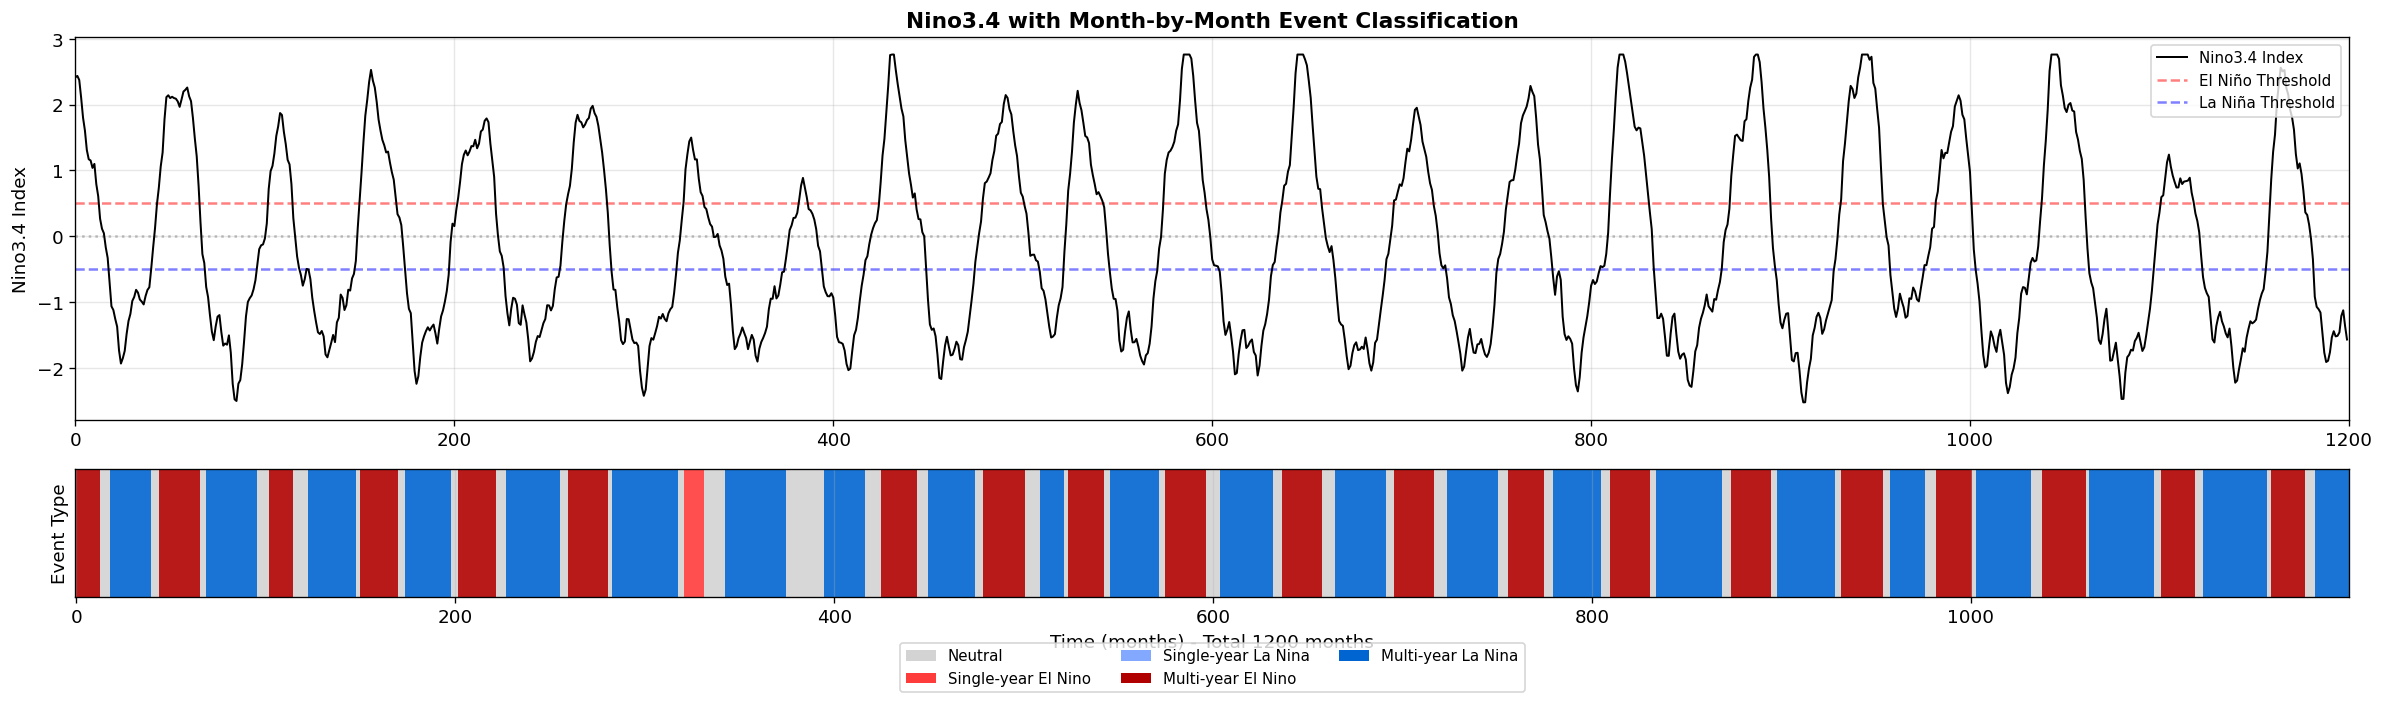

In [21]:
from matplotlib.patches import Patch

phase_color_map = {
    0: '#D3D3D3',  # Neutral
    1: '#FF3C3C',  # Single-year El Nino
    2: '#82A8FF',  # Single-year La Nina
    3: '#B10000',  # Multi-year El Nino
    4: '#0065D1',  # Multi-year La Nina
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6), height_ratios=[3, 1])

ax1.plot(enso_traj, linewidth=1.2, label='Nino3.4 Index', color='black', zorder=3)
ax1.set_xlim(0, T_traj)
ax1.axhline(THRESHOLD,  color='r', linestyle='--', alpha=0.5, linewidth=1.5, label='El Niño Threshold')
ax1.axhline(-THRESHOLD, color='b', linestyle='--', alpha=0.5, linewidth=1.5, label='La Niña Threshold')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax1.set_title("Nino3.4 with Month-by-Month Event Classification", fontsize=13, fontweight='bold')
ax1.set_ylabel("Nino3.4 Index")
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

bar_colors = [phase_color_map[int(l)] for l in labels_traj]
ax2.bar(range(T_traj), np.ones(T_traj), color=bar_colors, width=1, edgecolor='none', alpha=0.9)
ax2.set_xlim(-0.5, T_traj - 0.5)
ax2.set_ylim(0, 1)
ax2.set_xlabel(f"Time (months) - Total {T_traj} months")
ax2.set_yticks([])
ax2.set_ylabel("Event Type")
ax2.grid(True, alpha=0.3, axis='x')

legend_elements = [Patch(facecolor=phase_color_map[k], label=LABEL_NAMES[k]) for k in phase_color_map]
ax2.legend(handles=legend_elements, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, -0.3), frameon=True, fontsize=9)

fig.tight_layout()
plt.show()

### 0b. Styled ENSO table (Year x 3-month seasons) [NO Ensemble]

In [22]:
from utils.enso_table import create_enso_table, style_enso_table, save_enso_table_html
from IPython.display import display, HTML

df_enso = create_enso_table(enso_traj, threshold=THRESHOLD)
styler  = style_enso_table(df_enso, threshold=THRESHOLD)

# Save interactive HTML alongside the other rng-action plots
out_html = BASE / "enso_table.html"
save_enso_table_html(enso_traj, output_path=str(out_html), threshold=THRESHOLD)
print(f"Saved -> {out_html.resolve()}")

# Render inline (red = El Niño, blue = La Niña, peaks bolded)
display(HTML(styler.to_html()))

Saved -> /Users/ayman/research/enso-rl/plots/model2/enso_table.html


,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
Year,,,,,,,,,,,,
1,2.41,2.44,2.37,2.10,1.80,1.60,1.31,1.17,1.15,1.04,1.10,0.79
2,0.61,0.27,0.11,0.05,-0.17,-0.33,-0.70,-1.06,-1.12,-1.26,-1.37,-1.74
3,-1.93,-1.85,-1.74,-1.49,-1.29,-1.18,-0.98,-0.92,-0.81,-0.86,-0.96,-0.99
4,-1.04,-0.91,-0.82,-0.78,-0.49,-0.17,0.12,0.48,0.74,1.06,1.27,1.78
5,2.11,2.14,2.10,2.12,2.10,2.09,2.05,1.97,2.08,2.20,2.22,2.26
6,2.13,2.05,1.80,1.49,1.21,0.76,0.21,-0.27,-0.41,-0.77,-0.93,-1.20
7,-1.45,-1.58,-1.37,-1.22,-1.20,-1.46,-1.66,-1.63,-1.65,-1.51,-1.77,-2.24
8,-2.48,-2.50,-2.24,-2.19,-1.95,-1.60,-1.22,-1.00,-0.94,-0.90,-0.81,-0.67
9,-0.43,-0.20,-0.14,-0.12,-0.03,0.20,0.72,0.99,1.07,1.26,1.52,1.67


### 0c. State-variable time series (agent control) [No Ensemble]

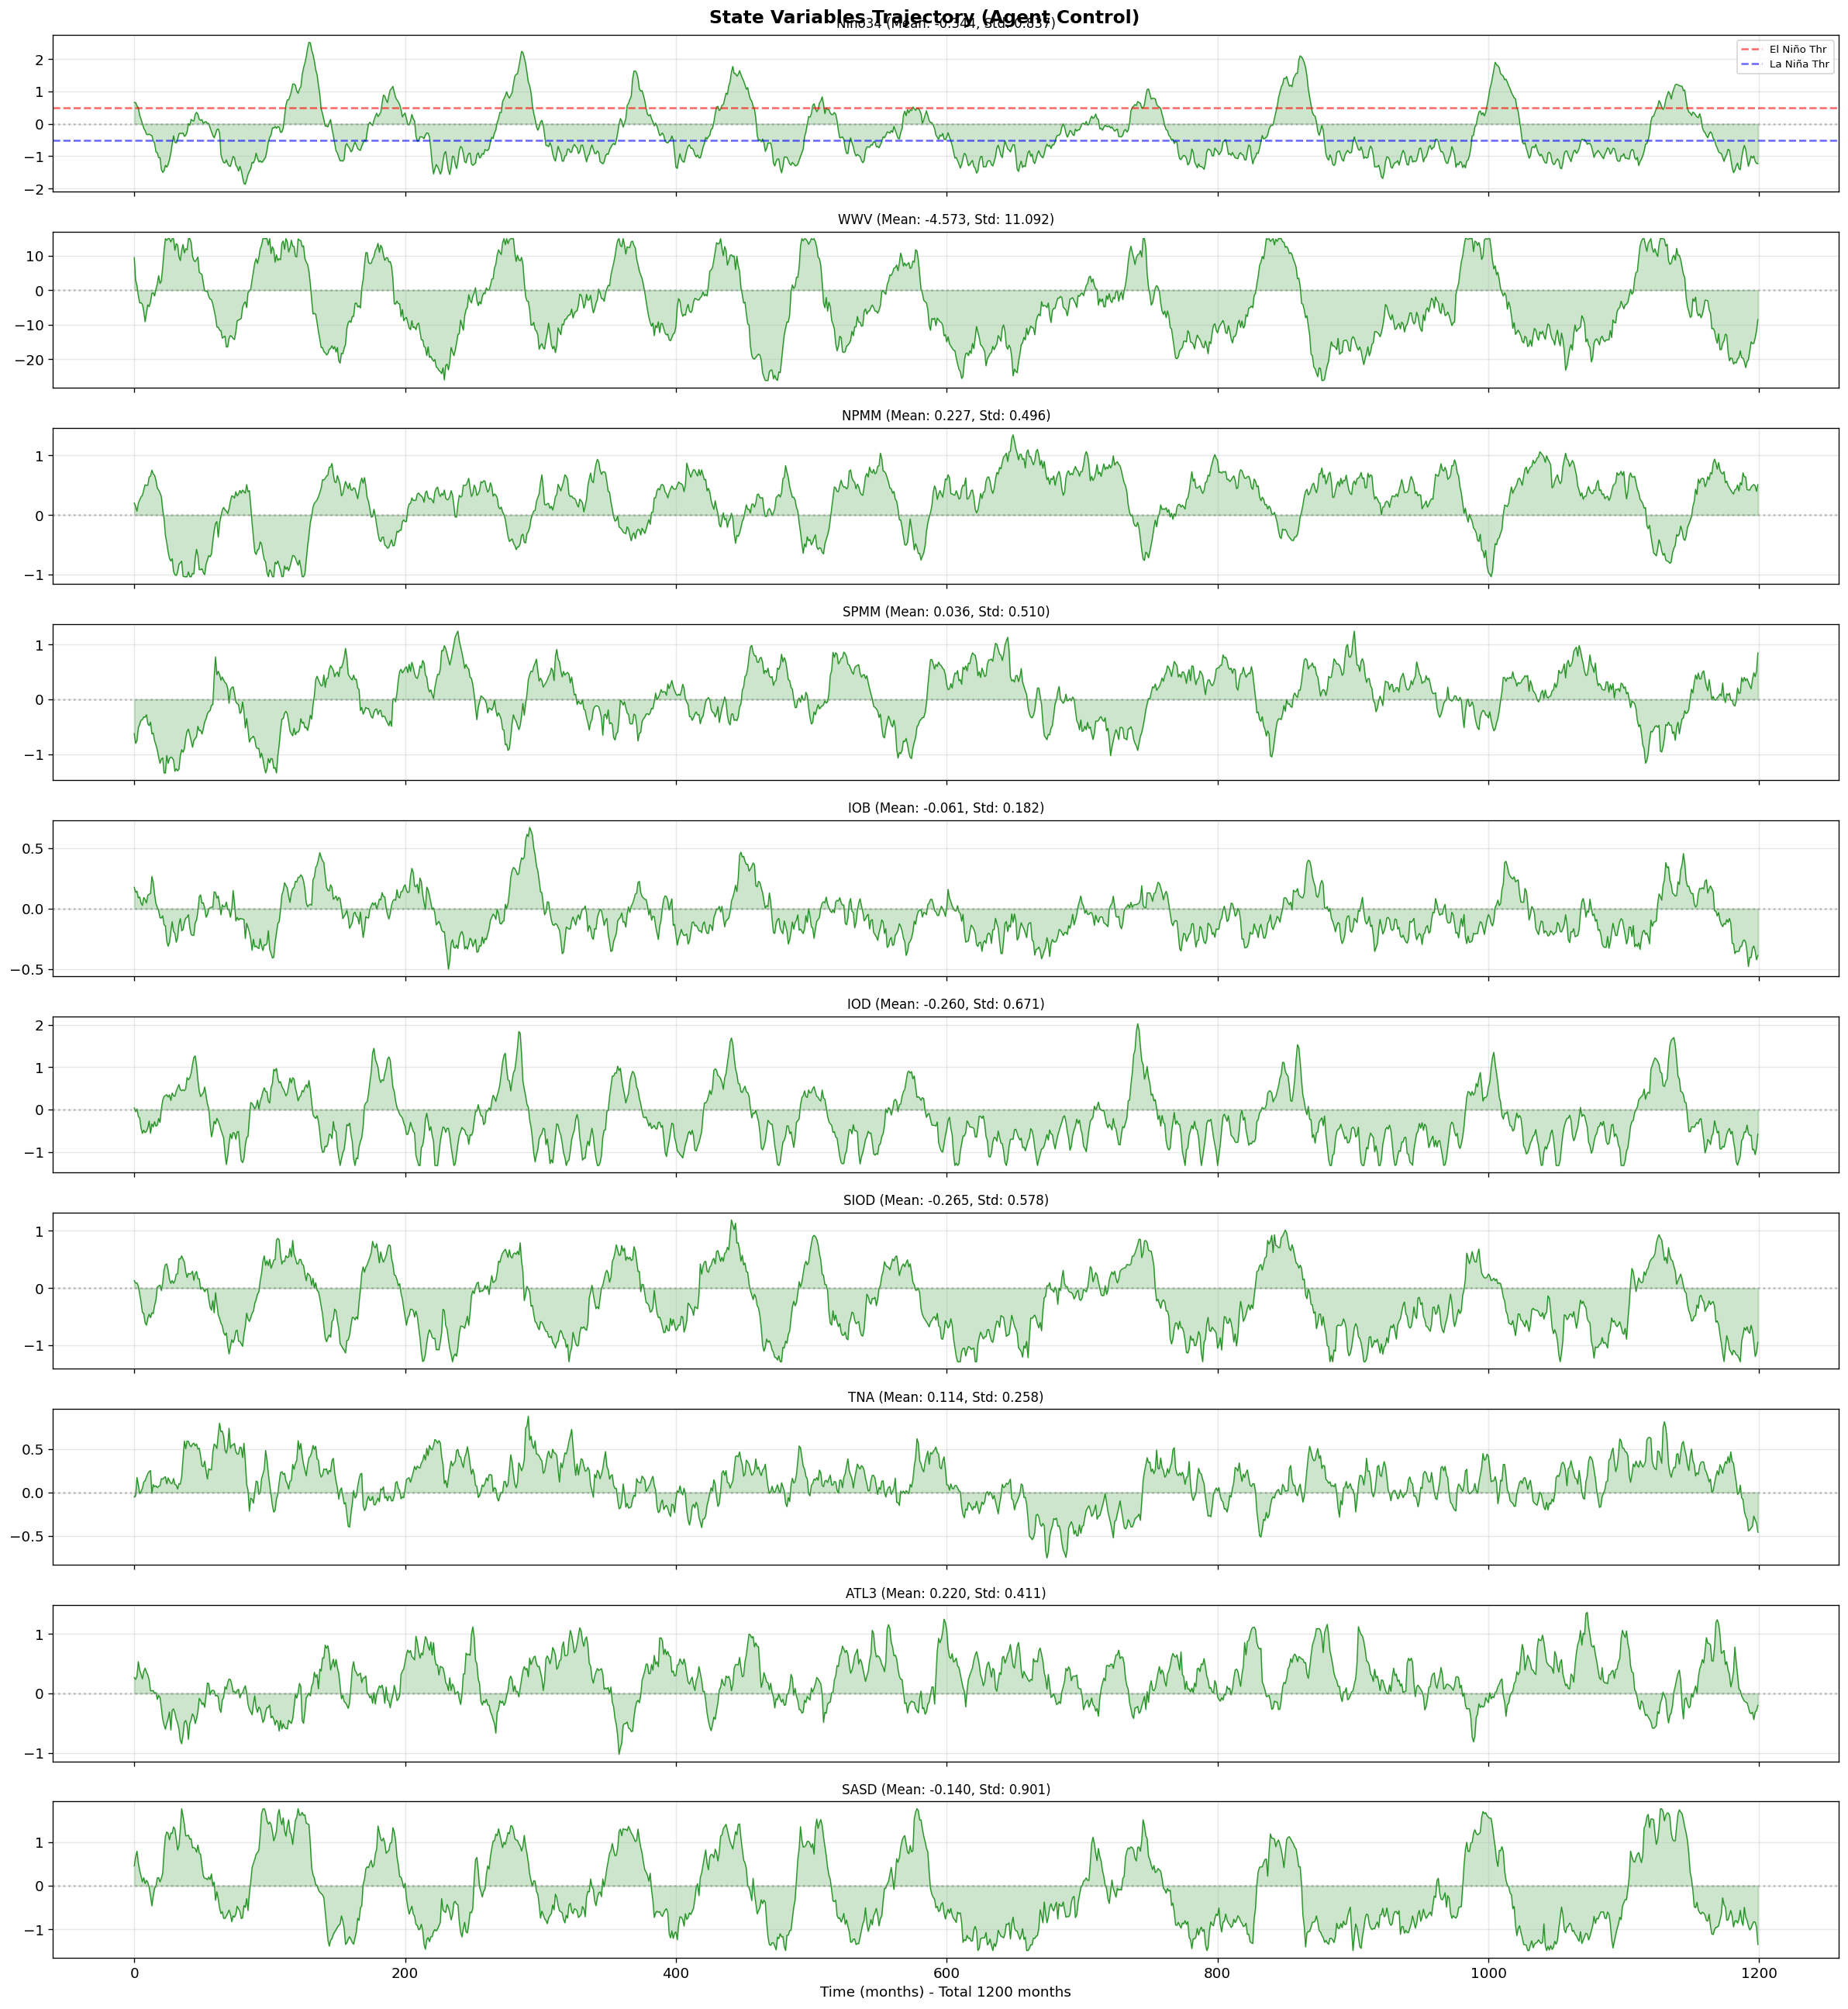

In [ ]:
n_vars = len(traj_var_names)
fig, axes = plt.subplots(n_vars, 1, figsize=(20, n_vars * 2.2), sharex=True)
fig.suptitle("State Variables Trajectory (Agent Control)", fontsize=14, fontweight='bold')

for i, vname in enumerate(traj_var_names):
    ax = axes[i]
    ax.plot(states_traj[:, i], linewidth=0.8, color='green', alpha=0.8)
    ax.fill_between(range(T_traj), states_traj[:, i], alpha=0.2, color='green')
    if vname == 'Nino34':
        ax.axhline(THRESHOLD,  color='r', linestyle='--', alpha=0.6, label='El Niño Thr')
        ax.axhline(-THRESHOLD, color='b', linestyle='--', alpha=0.6, label='La Niña Thr')
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{vname} (Mean: {states_traj[:, i].mean():.3f}, Std: {states_traj[:, i].std():.3f})',
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel(f"Time (months) - Total {T_traj} months")
fig.tight_layout()
plt.show()

### 0d. Control-action time series [No Ensemble]

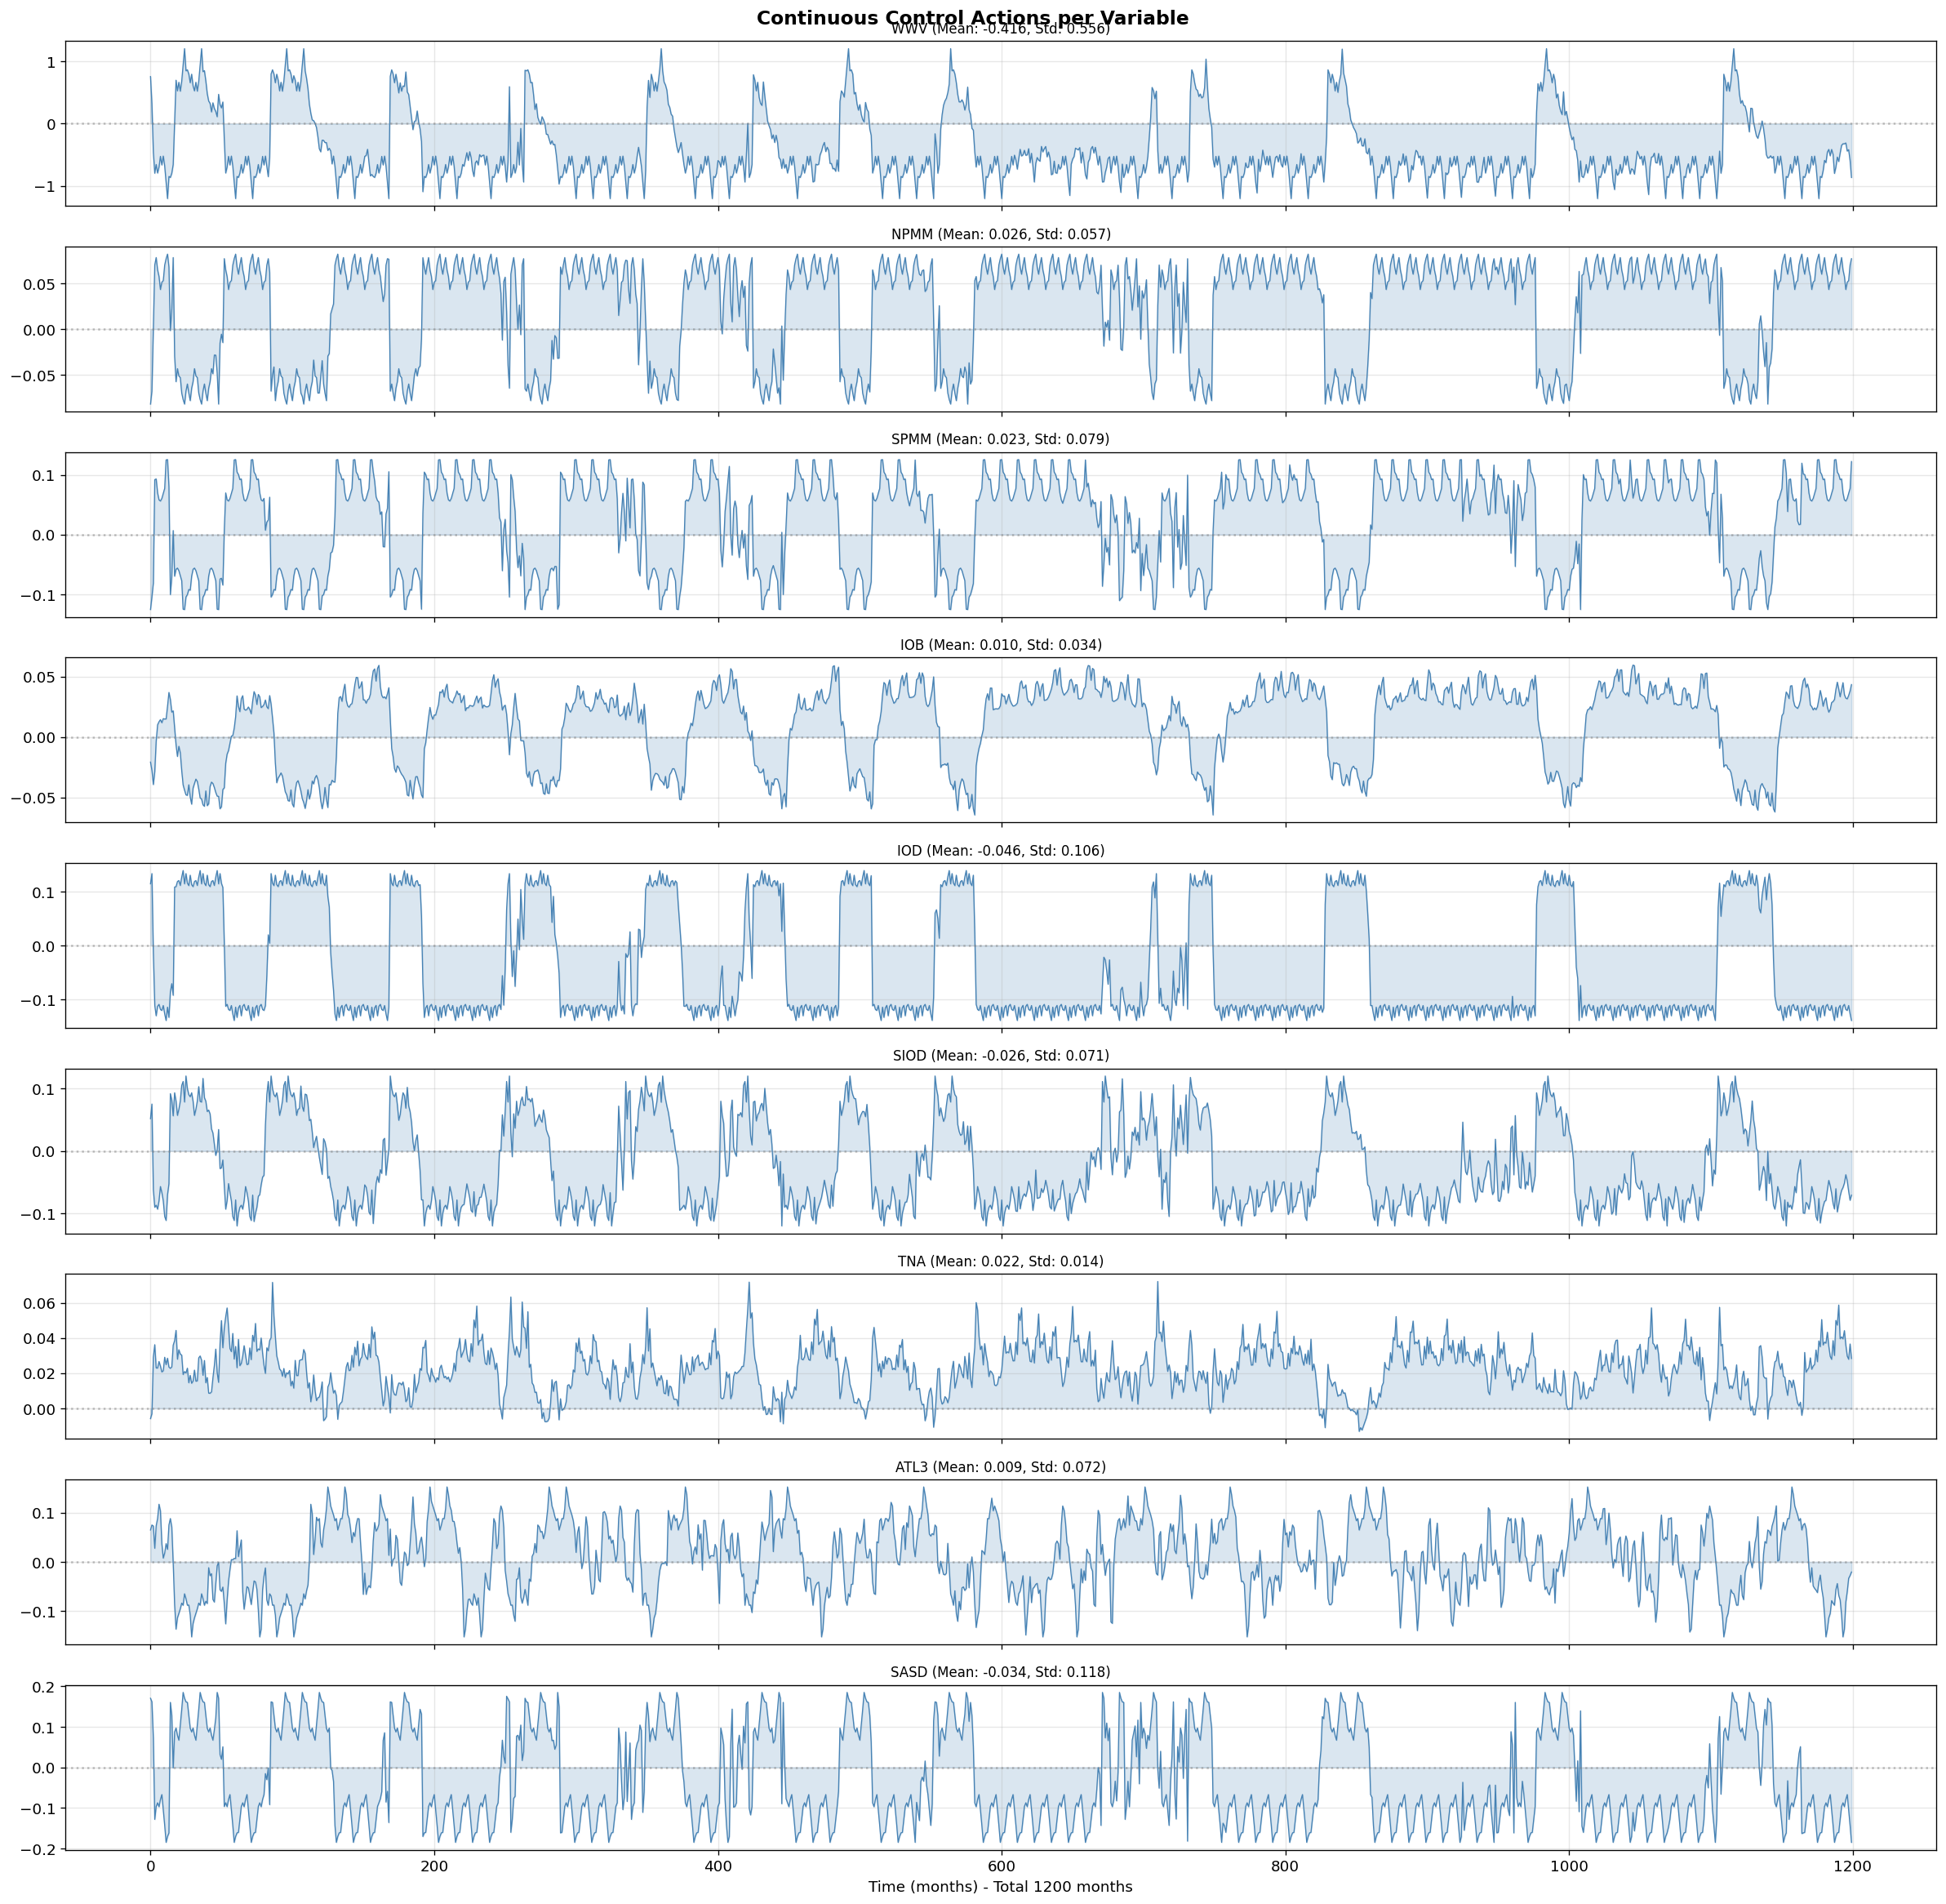

In [19]:
n_act = len(traj_action_names)
fig, axes = plt.subplots(n_act, 1, figsize=(20, n_act * 2.2), sharex=True)
fig.suptitle("Continuous Control Actions per Variable", fontsize=14, fontweight='bold')

for i, vname in enumerate(traj_action_names):
    ax = axes[i]
    ax.plot(actions_traj[:, i], linewidth=0.8, color='steelblue')
    ax.fill_between(range(T_traj), actions_traj[:, i], alpha=0.2, color='steelblue')
    ax.set_title(f'{vname} (Mean: {actions_traj[:, i].mean():.3f}, Std: {actions_traj[:, i].std():.3f})',
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)

axes[-1].set_xlabel(f"Time (months) - Total {T_traj} months")
fig.tight_layout()
plt.show()

### 0e. Action distributions by ENSO phase

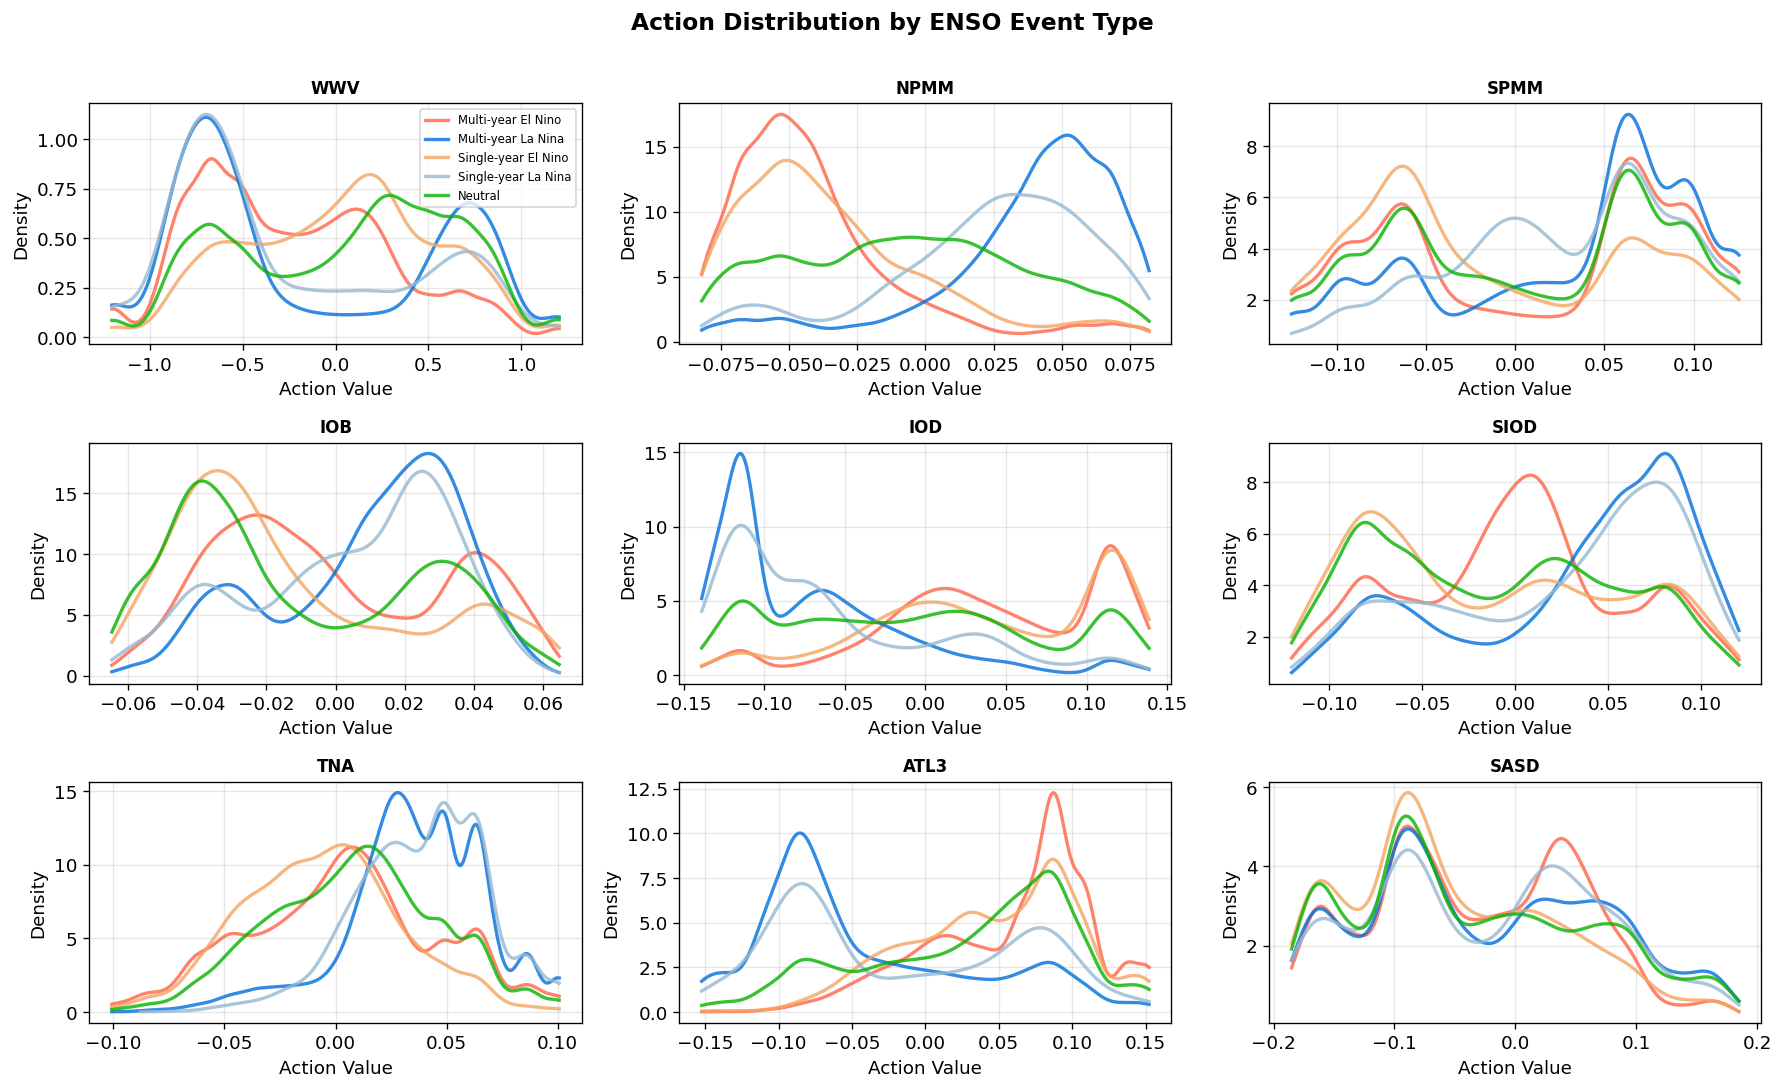

In [36]:
# Aggregated over ALL seeds x rollouts (not just the representative one) so each
# phase KDE has enough samples to be stable.
from scipy.stats import gaussian_kde

EVENT_ORDER      = [3, 4, 1, 2, 0]  # Multi-EN, Multi-LN, Single-EN, Single-LN, Neutral
kde_event_colors = {3: '#FF6347', 4: "#016EDB", 1: '#F4A460', 2: '#95B8D1', 0: "#09B200"}

all_labels = d_inf['agent_mye_label'].reshape(-1)   # [N]

def _kde_grid_by_event(data, names, title, xlabel, ncols=3, max_pts=20_000):
    """KDE of each column in `data`, one curve per ENSO phase, on a subplot grid."""
    rng = np.random.default_rng(0)
    n   = len(names)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes_flat = np.atleast_1d(axes).ravel()

    for i, name in enumerate(names):
        ax  = axes_flat[i]
        col = data[:, i]
        for ev in EVENT_ORDER:
            vals = col[all_labels == ev]
            if len(vals) < 10 or vals.std() < 1e-9:
                continue
            if len(vals) > max_pts:
                vals = vals[rng.choice(len(vals), max_pts, replace=False)]
            xs = np.linspace(vals.min(), vals.max(), 300)
            ax.plot(xs, gaussian_kde(vals)(xs), color=kde_event_colors[ev],
                    linewidth=2, alpha=0.8, label=LABEL_NAMES[ev])
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[n:]:
        ax.set_visible(False)
    axes_flat[0].legend(fontsize=7, loc='best')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.005)
    fig.tight_layout()
    plt.show()

all_actions = d_inf['agent_actions'].reshape(-1, len(traj_action_names))
_kde_grid_by_event(all_actions, traj_action_names,
                   "Action Distribution by ENSO Event Type", "Action Value")

### 0f. State distributions by ENSO phase

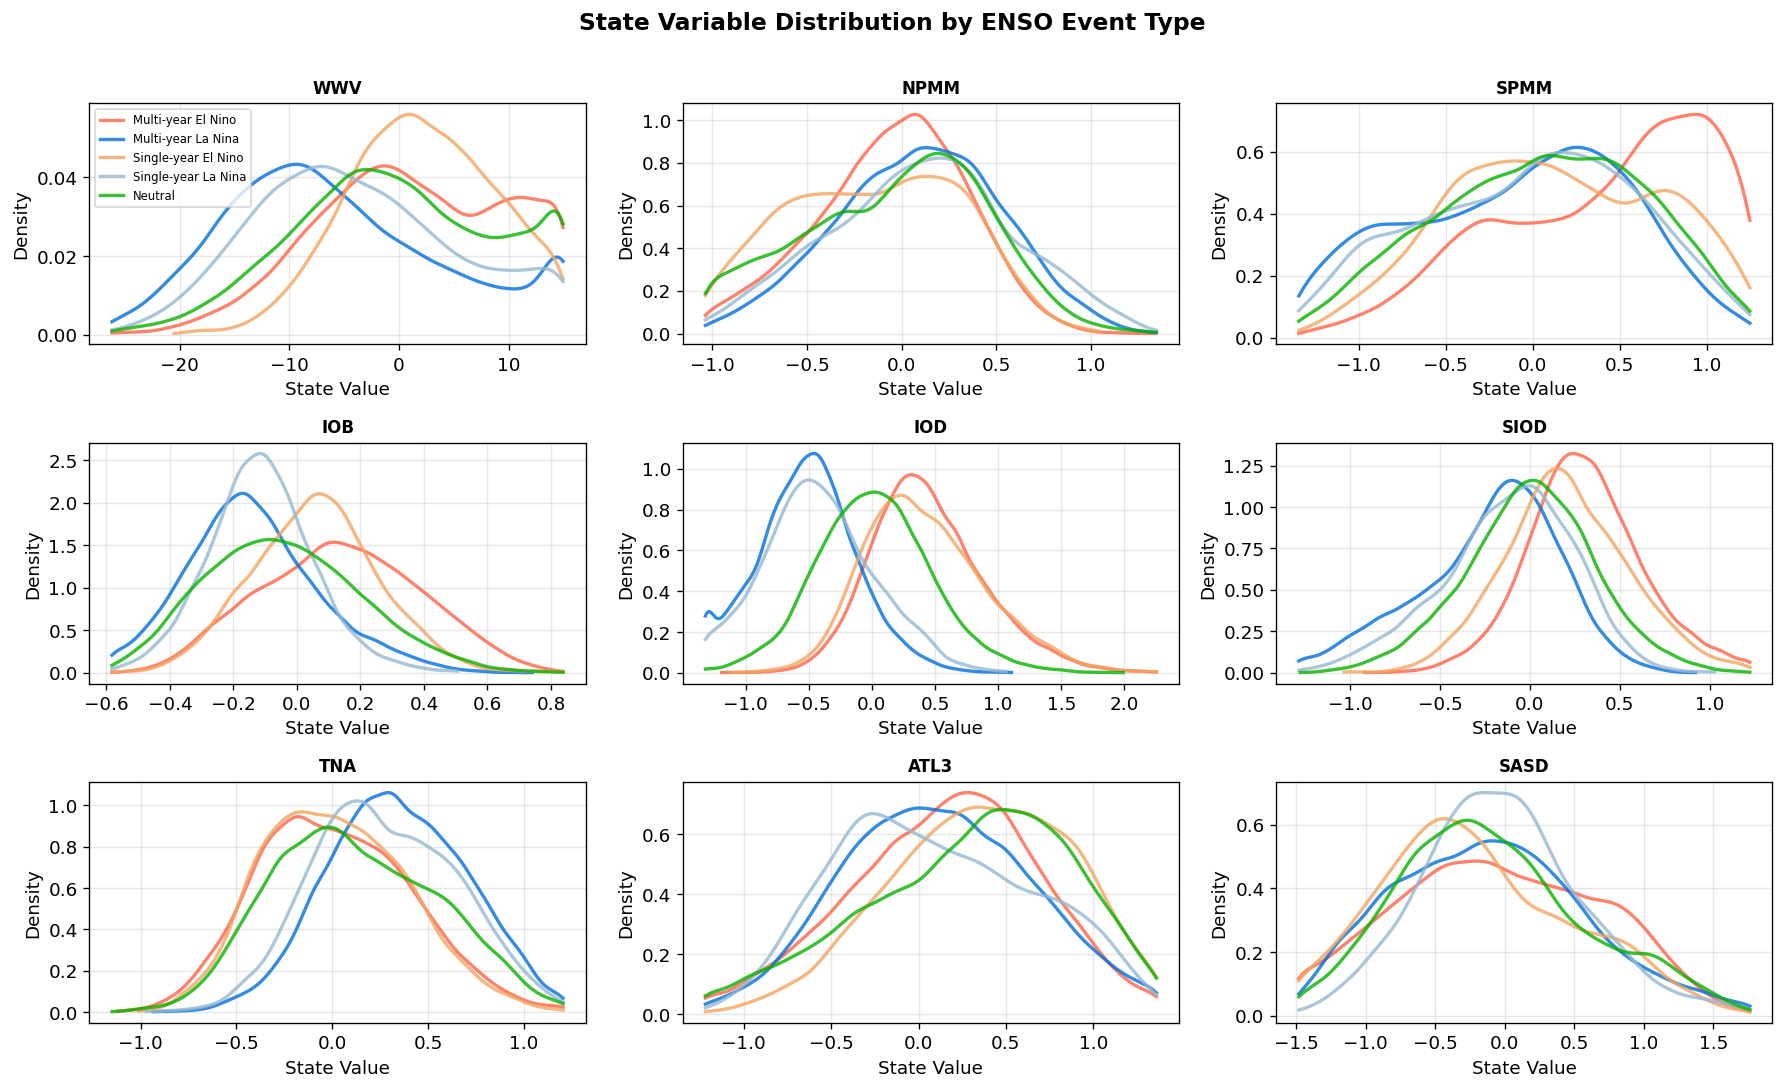

In [ ]:
all_states = d_inf['agent_obs'].reshape(-1, len(traj_var_names))[:,1:] # slice to skip Nino34
_kde_grid_by_event(all_states, traj_var_names[1:],
                   "State Variable Distribution by ENSO Event Type", "State Value")

---
## 1. Lift Analysis

ΔP(MYE) = agent probability − baseline probability, decomposed into frequency and duration changes.

In [22]:
# Load raw inference data (replaces old lift_ensemble.npz + CSVs)
d_inf = _load_npz(BASE / "inference.npz")
agent_label   = d_inf['agent_mye_label']   # [n_seeds, n_rollouts, T]
base_label    = d_inf['base_mye_label']
inf_var_names = list(d_inf['var_names'])
n_seeds_inf, n_rollouts_inf, T_inf = agent_label.shape

# --- Lift per phase: fraction of steps in each MYE category ---
lift_per_rollout = {}
per_seed_lift    = {}
agent_frac_all   = {}
base_frac_all    = {}

for phase, fn in PHASE_MASKS.items():
    a_frac = fn(agent_label).mean(axis=-1)   # [n_seeds, n_rollouts]
    b_frac = fn(base_label).mean(axis=-1)
    agent_frac_all[phase]   = a_frac
    base_frac_all[phase]    = b_frac
    lift_per_rollout[phase] = a_frac - b_frac
    per_seed_lift[phase]    = lift_per_rollout[phase].mean(axis=1)  # [n_seeds]

# CI and p-value across seeds (each seed = mean of its rollouts)
lift_summary = {}
for phase in PHASES:
    arr = per_seed_lift[phase]
    _, pval = ttest_1samp(arr, 0.0)
    lift_summary[phase] = dict(
        lift=arr.mean(),
        ci95=t_dist.ppf(0.975, df=len(arr)-1) * arr.std(ddof=1) / np.sqrt(len(arr)),
        pval=pval,
    )

print(f"Loaded: {n_seeds_inf} seeds × {n_rollouts_inf} rollouts × {T_inf} months")
for phase in PHASES:
    s = lift_summary[phase]
    print(f"  {phase:<8}  lift={s['lift']:+.4f}  CI95=±{s['ci95']:.4f}  "
          f"p={s['pval']:.4f}  {_sig_stars(s['pval'])}")

Loaded: 5 seeds × 30 rollouts × 1200 months
  total     lift=+0.1737  CI95=±0.2531  p=0.1294  ns
  el_nino   lift=-0.0349  CI95=±0.1355  p=0.5139  ns
  la_nina   lift=+0.2086  CI95=±0.2518  p=0.0830  ns


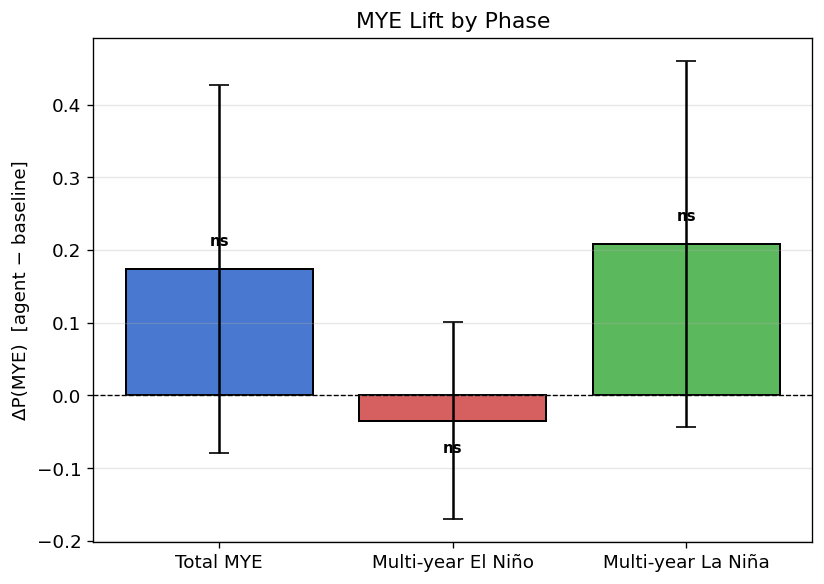

In [23]:
# --- 1a. Lift bar chart per phase ---
fig, ax = plt.subplots(figsize=(7, 5))
x      = np.arange(len(PHASES))
labels = [PHASE_LABELS[p] for p in PHASES]
lifts  = np.array([lift_summary[p]['lift']  for p in PHASES])
ci95   = np.array([lift_summary[p]['ci95']  for p in PHASES])
pvals  = np.array([lift_summary[p]['pval']  for p in PHASES])
colors = [PHASE_COLORS[p] for p in PHASES]

ax.bar(x, lifts, color=colors, edgecolor="black", linewidth=1.2,
       yerr=ci95, capsize=6, error_kw={"linewidth": 1.5})
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
_add_sig_labels(ax, x, lifts, pvals)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("ΔP(MYE)  [agent − baseline]")
ax.set_title("MYE Lift by Phase")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

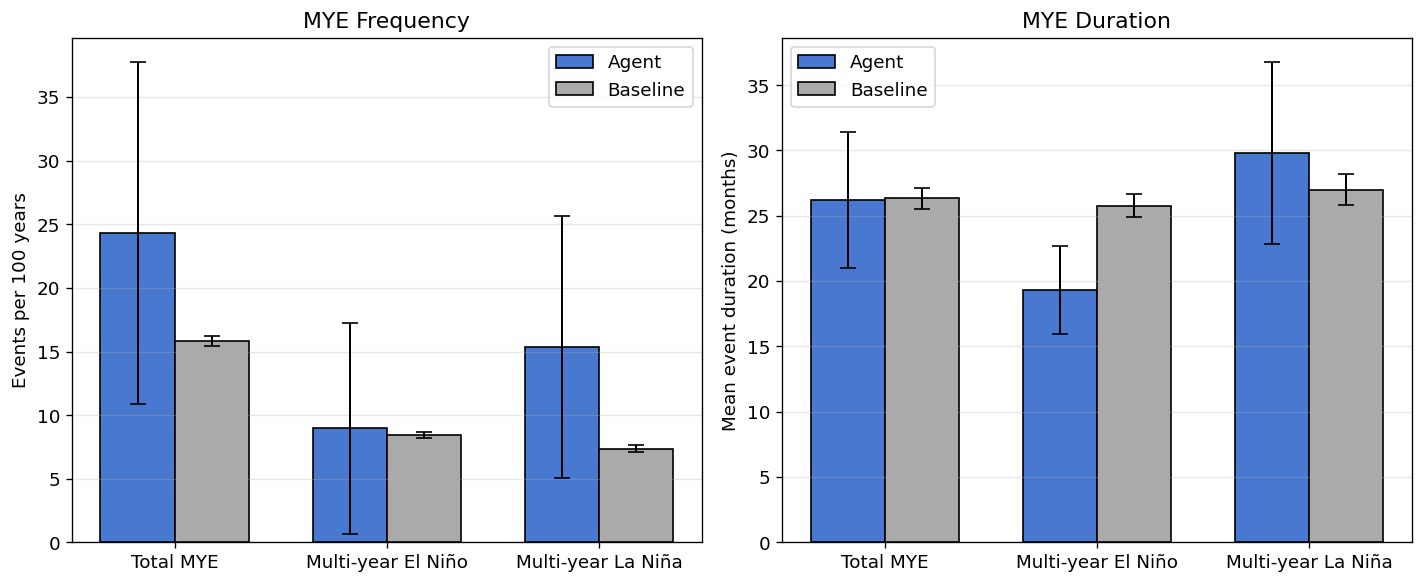

In [24]:
# --- 1b. Frequency & duration decomposition ---
# Count events and measure durations from raw labels via _find_continuous_runs
years_per_rollout = T_inf / 12
century_scale     = 100.0 / years_per_rollout

freq_agent = {p: np.zeros(n_seeds_inf) for p in PHASES}
freq_base  = {p: np.zeros(n_seeds_inf) for p in PHASES}
dur_agent  = {p: np.zeros(n_seeds_inf) for p in PHASES}
dur_base   = {p: np.zeros(n_seeds_inf) for p in PHASES}

for si in range(n_seeds_inf):
    for phase, fn in PHASE_MASKS.items():
        cnts_a, durs_a, cnts_b, durs_b = [], [], [], []
        for ri in range(n_rollouts_inf):
            runs_a = _find_continuous_runs(fn(agent_label[si, ri]).astype(int))
            cnts_a.append(len(runs_a))
            durs_a.extend([r[2] for r in runs_a])
            runs_b = _find_continuous_runs(fn(base_label[si, ri]).astype(int))
            cnts_b.append(len(runs_b))
            durs_b.extend([r[2] for r in runs_b])
        freq_agent[phase][si] = np.mean(cnts_a) * century_scale
        freq_base[phase][si]  = np.mean(cnts_b) * century_scale
        dur_agent[phase][si]  = np.mean(durs_a) if durs_a else 0.0
        dur_base[phase][si]   = np.mean(durs_b) if durs_b else 0.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x      = np.arange(len(PHASES))
labels = [PHASE_LABELS[p] for p in PHASES]
w      = 0.35

ax = axes[0]
for i, phase in enumerate(PHASES):
    mA, cA = _mean_ci(freq_agent[phase])
    mB, cB = _mean_ci(freq_base[phase])
    ax.bar(i - w/2, mA, w, label="Agent"    if i == 0 else "", color="#4878CF",
           yerr=cA, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
    ax.bar(i + w/2, mB, w, label="Baseline" if i == 0 else "", color="#aaaaaa",
           yerr=cB, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Events per 100 years")
ax.set_title("MYE Frequency")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
for i, phase in enumerate(PHASES):
    mA, cA = _mean_ci(dur_agent[phase])
    mB, cB = _mean_ci(dur_base[phase])
    ax.bar(i - w/2, mA, w, label="Agent"    if i == 0 else "", color="#4878CF",
           yerr=cA, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
    ax.bar(i + w/2, mB, w, label="Baseline" if i == 0 else "", color="#aaaaaa",
           yerr=cB, capsize=5, error_kw={"linewidth": 1.2}, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Mean event duration (months)")
ax.set_title("MYE Duration")
ax.legend(); ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

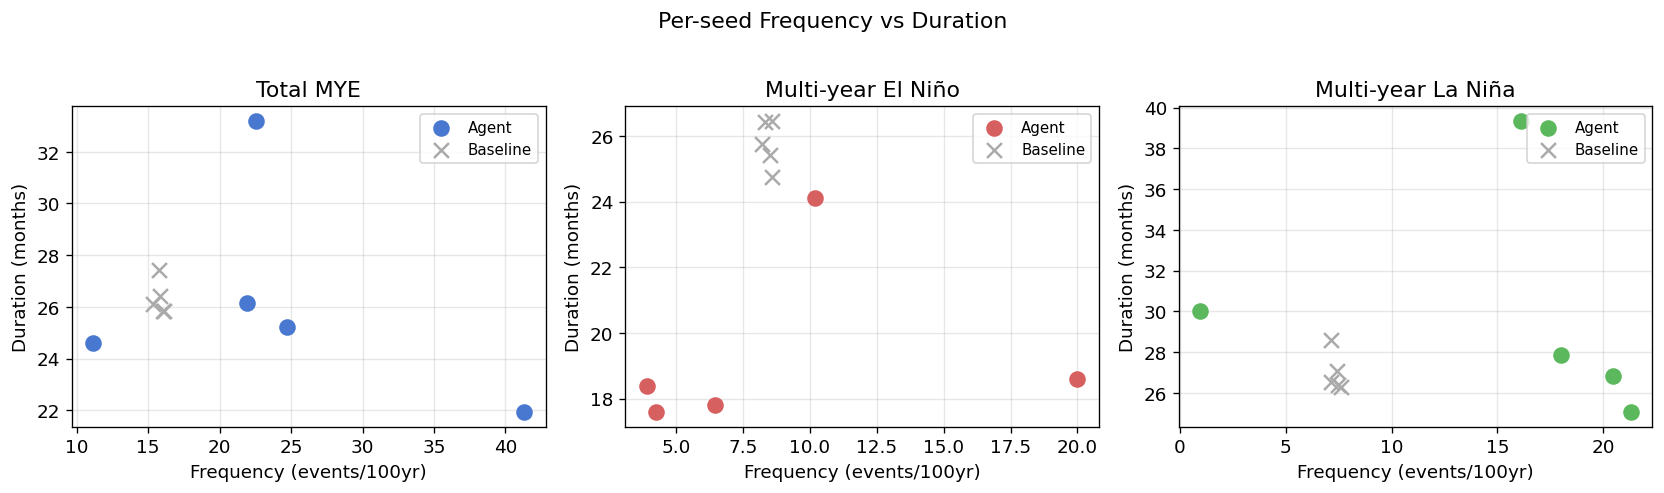

In [25]:
# --- 1c. Per-seed freq–duration scatter (robustness check) ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(14, 4), sharey=False)
for ax, phase in zip(axes, PHASES):
    ax.scatter(freq_agent[phase], dur_agent[phase],
               color=PHASE_COLORS[phase], s=80, zorder=3, label="Agent")
    ax.scatter(freq_base[phase], dur_base[phase],
               color="#aaaaaa", marker="x", s=80, zorder=3, label="Baseline")
    ax.set_xlabel("Frequency (events/100yr)")
    ax.set_ylabel("Duration (months)")
    ax.set_title(PHASE_LABELS[phase])
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.suptitle("Per-seed Frequency vs Duration", y=1.02)
fig.tight_layout()
plt.show()

---
## 2. Counterfactual Analysis

Zero-ablation of each action dimension. ΔP(MYE) measures how much removing a mode degrades (or improves) the agent's ability to sustain multi-year ENSO.

In [7]:
cf_dir = BASE / "counterfactual"
d_cf   = _load_npz(cf_dir / "counterfactual_ensemble.npz")

features = list(d_cf["features"])  # ['WWV', 'NPMM', ...]

# Build p-values: prefer stored p_* keys; fall back to computing from per_seed
cf_pvals = {}
for p in PHASES:
    if f"p_{p}" in d_cf.files:
        cf_pvals[p] = d_cf[f"p_{p}"]
    elif f"per_seed_{p}" in d_cf.files:
        M = d_cf[f"per_seed_{p}"]  # [n_seeds, n_features]
        cf_pvals[p] = np.array([ttest_1samp(M[:, fi], 0).pvalue for fi in range(M.shape[1])])
    else:
        cf_pvals[p] = np.ones(len(features))

print(f"Features: {features}")
print(f"Phases: {list(d_cf['phases'])}")

FileNotFoundError: [Errno 2] No such file or directory: '../plots/rng-action/counterfactual/counterfactual_ensemble.npz'

NameError: name 'd_cf' is not defined

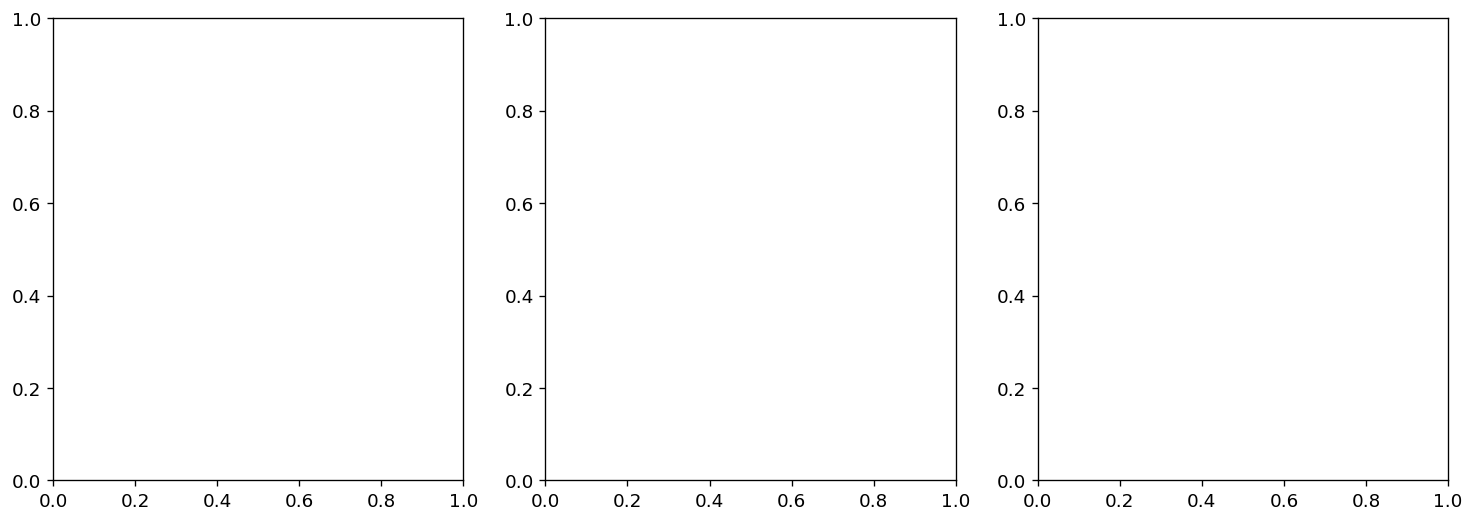

In [8]:
# --- 2. Counterfactual ΔP bars per phase ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
for ax, phase in zip(axes, PHASES):
    means = d_cf[f"mean_{phase}"]
    cis   = d_cf[f"ci_{phase}"]
    pvals = cf_pvals[phase]

    order = np.argsort(means)[::-1]
    names_s = [features[i] for i in order]
    means_s = means[order]
    cis_s   = cis[order]
    pvals_s = pvals[order]

    colors = [PHASE_COLORS[phase] if p < 0.05 else "#cccccc" for p in pvals_s]
    x = np.arange(len(features))
    ax.bar(x, means_s, color=colors, edgecolor="black", linewidth=1.0,
           yerr=cis_s, capsize=5, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    _add_sig_labels(ax, x, means_s, pvals_s)
    ax.set_xticks(x); ax.set_xticklabels(names_s, rotation=45, ha="right")
    ax.set_ylabel("ΔP(MYE) after zero-ablation")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Counterfactual Analysis — Driver Importance", fontsize=13)
fig.tight_layout()
plt.show()

---
## 3. Shapley Analysis

Permutation-based Shapley values across seeds — a game-theoretic attribution of each mode's marginal contribution to the agent's MYE lift.

In [ ]:
sh_dir = BASE / "shapley"
d_sh   = _load_npz(sh_dir / "shapley_ensemble.npz")

sh_features = list(d_sh["features"])

sh_pvals = {}
for p in PHASES:
    if f"p_{p}" in d_sh.files:
        sh_pvals[p] = d_sh[f"p_{p}"]
    elif f"per_seed_{p}" in d_sh.files:
        M = d_sh[f"per_seed_{p}"]
        sh_pvals[p] = np.array([ttest_1samp(M[:, fi], 0).pvalue for fi in range(M.shape[1])])
    else:
        sh_pvals[p] = np.ones(len(sh_features))

print(f"Features: {sh_features}")

In [ ]:
# --- 3a. Shapley bars per phase ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
for ax, phase in zip(axes, PHASES):
    means = d_sh[f"mean_{phase}"]
    cis   = d_sh[f"ci_{phase}"]
    pvals = sh_pvals[phase]

    order = np.argsort(means)[::-1]
    names_s = [sh_features[i] for i in order]
    means_s = means[order]
    cis_s   = cis[order]
    pvals_s = pvals[order]

    colors = [PHASE_COLORS[phase] if p < 0.05 else "#cccccc" for p in pvals_s]
    x = np.arange(len(sh_features))
    ax.bar(x, means_s, color=colors, edgecolor="black", linewidth=1.0,
           yerr=cis_s, capsize=5, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    _add_sig_labels(ax, x, means_s, pvals_s)
    ax.set_xticks(x); ax.set_xticklabels(names_s, rotation=45, ha="right")
    ax.set_ylabel("Shapley value (ΔP contribution)")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Shapley Attribution — Driver Importance", fontsize=13)
fig.tight_layout()
plt.show()

In [ ]:
# --- 3b. Per-seed Shapley heatmap (if per_seed_* arrays available) ---
if "per_seed_total" in d_sh.files:
    M = d_sh["per_seed_total"]  # [n_seeds, n_features]
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(M.T, cmap="RdBu_r", aspect="auto",
                   norm=mcolors.TwoSlopeNorm(vcenter=0))
    ax.set_yticks(range(len(sh_features))); ax.set_yticklabels(sh_features)
    ax.set_xlabel("Seed index")
    ax.set_title("Shapley values per seed (Total MYE)")
    plt.colorbar(im, ax=ax, label="Shapley value")
    fig.tight_layout()
    plt.show()
else:
    print("per_seed_* arrays not in shapley npz — re-run shapley_analysis.py to populate.")

---
## 4. Driver Convergence

Z-scored overlay of counterfactual, Shapley, and interventional methods. When all three agree, the driver ranking is robust. Spearman ρ quantifies cross-method consistency.

In [ ]:
d_iv = _load_npz(BASE / "interventional_xro" / "interventional_xro.npz")

iv_targets = list(d_iv["targets"])    # e.g. 'WWV_+', 'WWV_-', ...
iv_phases  = list(d_iv["phases"])
iv_means   = d_iv["mean"]
iv_signs   = list(d_iv["signs"])

def _iv_for_phase(phase, features):
    """Return best (max absolute) ΔP per feature for a given phase from interventional."""
    vals = np.zeros(len(features))
    for i, feat in enumerate(features):
        idxs = [j for j, (t, ph) in enumerate(zip(iv_targets, iv_phases))
                if ph == phase and t.startswith(feat)]
        if idxs:
            vals[i] = iv_means[idxs][np.argmax(np.abs(iv_means[idxs]))]
    return vals

print(f"Interventional: {len(iv_targets)} target×phase entries")

In [ ]:
# --- 4. Z-scored driver convergence overlay ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
x = np.arange(len(features))
w = 0.25

for ax, phase in zip(axes, PHASES):
    cf_z  = _zscore(d_cf[f"mean_{phase}"])
    sh_z  = _zscore(d_sh[f"mean_{phase}"])
    iv_z  = _zscore(_iv_for_phase(phase, features))

    ax.bar(x - w, cf_z, w, label="Counterfactual", color="#4878CF", edgecolor="black", linewidth=0.8)
    ax.bar(x,     sh_z, w, label="Shapley",         color="#D65F5F", edgecolor="black", linewidth=0.8)
    ax.bar(x + w, iv_z, w, label="Interventional",  color="#5CB85C", edgecolor="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xticks(x); ax.set_xticklabels(features, rotation=45, ha="right")
    ax.set_ylabel("Z-score")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

    # Spearman ρ
    rho_cf_sh, _ = spearmanr(cf_z, sh_z)
    rho_cf_iv, _ = spearmanr(cf_z, iv_z)
    rho_sh_iv, _ = spearmanr(sh_z, iv_z)
    ax.set_xlabel(f"ρ(CF,Sh)={rho_cf_sh:.2f}  ρ(CF,IV)={rho_cf_iv:.2f}  ρ(Sh,IV)={rho_sh_iv:.2f}",
                  fontsize=8)

axes[0].legend(fontsize=9)
fig.suptitle("Driver Convergence — Z-scored Cross-Method Comparison", fontsize=13)
fig.tight_layout()
plt.show()

---
## 5. Seed Sensitivity

Robustness of results across independently trained seeds. We check (a) whether the El Niño vs La Niña lift asymmetry is consistent per seed, and (b) whether driver rankings from counterfactual and Shapley are stable across seeds.

In [ ]:
# per_seed_lift computed in Section 1 from inference.npz
lift_en = per_seed_lift['el_nino']   # [n_seeds]
lift_ln = per_seed_lift['la_nina']   # [n_seeds]
n_seeds = len(lift_en)
print(f"Seeds: {n_seeds}  |  El Niño lift: {lift_en.mean():.3f} ± {lift_en.std():.3f}")
print(f"                    La Niña lift: {lift_ln.mean():.3f} ± {lift_ln.std():.3f}")

In [ ]:
# --- 5a. EN vs LN lift scatter per seed ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(lift_en, lift_ln, s=80, color="#4878CF", edgecolor="black", zorder=3)
for i, (x_, y_) in enumerate(zip(lift_en, lift_ln)):
    ax.text(x_ + 0.005, y_ + 0.005, str(i), fontsize=8)
lims = [min(lift_en.min(), lift_ln.min()) - 0.05,
        max(lift_en.max(), lift_ln.max()) + 0.05]
ax.plot(lims, lims, "k--", linewidth=0.8, label="EN = LN")
ax.axhline(0, color="grey", linewidth=0.6); ax.axvline(0, color="grey", linewidth=0.6)
ax.set_xlabel("Multi-year El Niño lift"); ax.set_ylabel("Multi-year La Niña lift")
ax.set_title("Per-seed EN vs LN Lift Asymmetry")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
# --- 5b. Seed × mode heatmaps (CF and Shapley, total phase) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (d, label) in zip(axes, [(d_cf, "Counterfactual"), (d_sh, "Shapley")]):
    if "per_seed_total" in d.files:
        M = d["per_seed_total"]   # [n_seeds, n_features]
        feat = list(d["features"])
        im = ax.imshow(M, cmap="RdBu_r", aspect="auto",
                       norm=mcolors.TwoSlopeNorm(vcenter=0))
        ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=45, ha="right")
        ax.set_yticks(range(M.shape[0])); ax.set_yticklabels([f"seed {i}" for i in range(M.shape[0])])
        ax.set_title(f"{label} — per seed (Total MYE)")
        plt.colorbar(im, ax=ax, label="ΔP")
    else:
        ax.text(0.5, 0.5, f"per_seed_total\nnot in {label} npz\n(re-run script)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set_title(f"{label} — per seed (Total MYE)")

fig.tight_layout()
plt.show()

---
## 6. Interventional XRO

Direct mode-press and mode-brake interventions in a free XRO. Shows which modes, when externally sustained or suppressed, causally change MYE probability.

In [ ]:
# interventional_xro.npz keys: targets, signs, phases, mean, ci, p
iv_df = pd.DataFrame({
    "target": list(d_iv["targets"]),
    "sign":   list(d_iv["signs"]),
    "phase":  list(d_iv["phases"]),
    "mean":   d_iv["mean"],
    "ci":     d_iv["ci"],
    "p":      d_iv["p"] if "p" in d_iv.files else np.ones(len(d_iv["targets"])),
})
# Extract mode name (everything before last _)
iv_df["mode"] = iv_df["target"].str.rsplit("_", n=1).str[0]
print(iv_df.head(6).to_string())

In [ ]:
# --- 6. Interventional ΔP bars per phase ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
for ax, phase in zip(axes, PHASES):
    sub = iv_df[iv_df["phase"] == phase].copy()
    sub = sub.sort_values("mean", ascending=False)

    colors = ["#D65F5F" if s == "+" else "#4878CF" for s in sub["sign"]]
    colors = [c if p < 0.05 else "#cccccc" for c, p in zip(colors, sub["p"])]

    x = np.arange(len(sub))
    ax.bar(x, sub["mean"], color=colors, edgecolor="black", linewidth=0.8,
           yerr=sub["ci"], capsize=5, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    _add_sig_labels(ax, x, sub["mean"].values, sub["p"].values)
    ax.set_xticks(x); ax.set_xticklabels(sub["target"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("ΔP(MYE)")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#D65F5F", label="Sustain (+)"),
              Patch(facecolor="#4878CF", label="Brake (−)"),
              Patch(facecolor="#cccccc", label="ns")]
axes[0].legend(handles=legend_els, fontsize=9)
fig.suptitle("Interventional XRO — Mode-Specific Causal Effect", fontsize=13)
fig.tight_layout()
plt.show()

---
## 7. Seasonality of Control

When in the seasonal cycle does the agent act most strongly? Highlights the spring predictability barrier (Mar–May).

In [ ]:
# Reuse already-loaded d_inf (inference.npz) for seasonality
actions = d_inf['agent_actions']            # [n_seeds, n_rollouts, T, 9]
n_modes = actions.shape[-1]
drivers = list(d_inf['action_names'])       # 9 forcing modes (no Nino3.4)
T_seas  = actions.shape[2]
SPINUP_seas = int(d_inf['spinup'])          # == 12

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
spring_idx  = [2, 3, 4]

# Month index for each timestep; skip first SPINUP months of each rollout
month_idx  = np.arange(T_seas) % 12
keep_mask  = np.arange(T_seas) >= SPINUP_seas

# Per-rollout monthly means → [n_seeds, n_rollouts, 12, n_modes]
abs_by_month    = np.zeros((n_seeds_inf, n_rollouts_inf, 12, n_modes))
signed_by_month = np.zeros((n_seeds_inf, n_rollouts_inf, 12, n_modes))
for m in range(12):
    sel = keep_mask & (month_idx == m)
    abs_by_month[:, :, m, :]    = np.abs(actions[:, :, sel, :]).mean(axis=2)
    signed_by_month[:, :, m, :] = actions[:, :, sel, :].mean(axis=2)

# Ensemble mean and SEM over seeds × rollouts
abs_mean    = abs_by_month.mean(axis=(0, 1))      # [12, n_modes]
abs_sem     = abs_by_month.std(axis=(0, 1), ddof=1) / np.sqrt(n_seeds_inf * n_rollouts_inf)
signed_mean = signed_by_month.mean(axis=(0, 1))   # [12, n_modes]
total_by_month = abs_mean.sum(axis=1)             # [12]

spring_frac = total_by_month[spring_idx].sum() / total_by_month.sum()
print(f"Spring (Mar-May) share: {spring_frac*100:.1f}%  (even = 25.0%)")
print(f"Modes: {drivers}")

In [ ]:
# --- 7a. Month × mode heatmap (absolute forcing) ---
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(abs_mean.T, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(12)); ax.set_xticklabels(month_names)
ax.set_yticks(range(n_modes)); ax.set_yticklabels(drivers)
ax.set_title("Mean |Scaled Forcing| by Calendar Month × Mode")
plt.colorbar(im, ax=ax, label="Mean |forcing|")
for m in spring_idx:
    ax.axvline(m - 0.5, color="cyan", linewidth=2)
    ax.axvline(m + 0.5, color="cyan", linewidth=2)
fig.tight_layout()
plt.show()

In [ ]:
# --- 7b. Monthly total forcing bar ---
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#E57373" if m in spring_idx else "#90CAF9" for m in range(12)]
ax.bar(range(12), total_by_month, color=bar_colors, edgecolor="black", linewidth=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(month_names)
ax.set_ylabel("Total |scaled forcing| (sum over modes)")
ax.set_title(f"Monthly Forcing Total  |  Spring share = {spring_frac*100:.1f}%")
ax.grid(axis="y", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#E57373", label="Spring (Mar-May)"),
                   Patch(facecolor="#90CAF9", label="Other months")], fontsize=9)
fig.tight_layout()
plt.show()

---
## 8. Precursor Composite

Mean XRO state in the months preceding spontaneous multi-year ENSO events in a free-running emulator (no agent). Validates agent-discovered drivers against the emulator's own natural precursor patterns.

In [ ]:
prec_dir = BASE / "precursor_composite"
d_prec   = _load_npz(prec_dir / "precursor_composite.npz")

prec_vars = list(d_prec["var_names"])  # 10 modes
lead      = int(d_prec["lead"])
lag_months = np.arange(-lead, 0)

for p in PHASES:
    n = int(d_prec[f"{p}_n"])
    print(f"  {p:8s}: {n} events")

In [ ]:
# --- 8a. Precursor composite trajectories per phase (top 5 modes) ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
top_n = 5

for ax, phase in zip(axes, PHASES):
    n = int(d_prec[f"{phase}_n"])
    if n == 0:
        ax.text(0.5, 0.5, "No events", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(PHASE_LABELS[phase]); continue

    traj_mean = d_prec[f"{phase}_traj_mean"]  # [lead, n_modes]
    traj_ci   = d_prec[f"{phase}_traj_ci"]
    pat_mean  = d_prec[f"{phase}_pattern_mean"]

    # Pick top modes by absolute average precursor signal
    top_idx = np.argsort(np.abs(pat_mean))[::-1][:top_n]
    cmap = plt.get_cmap("tab10")
    for k, mi in enumerate(top_idx):
        col = cmap(k)
        y = traj_mean[:, mi]
        ci = traj_ci[:, mi]
        ax.plot(lag_months, y, color=col, label=prec_vars[mi], linewidth=2)
        ax.fill_between(lag_months, y - ci, y + ci, color=col, alpha=0.15)

    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.axvline(0, color="red", linewidth=1.0, linestyle=":", label="Onset")
    ax.set_xlabel("Months before onset")
    ax.set_ylabel("Normalised state")
    ax.set_title(f"{PHASE_LABELS[phase]} (N={n})")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("Spontaneous-MYE Precursor Composite (XRO, no agent)", fontsize=13)
fig.tight_layout()
plt.show()

In [ ]:
# --- 8b. Precursor pattern bar (lead-averaged) ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
for ax, phase in zip(axes, PHASES):
    n = int(d_prec[f"{phase}_n"])
    if n == 0:
        ax.text(0.5, 0.5, "No events", ha="center", va="center", transform=ax.transAxes); continue
    pat_mean = d_prec[f"{phase}_pattern_mean"]
    pat_ci   = d_prec[f"{phase}_pattern_ci"]
    order = np.argsort(pat_mean)[::-1]
    x = np.arange(len(prec_vars))
    colors = [PHASE_COLORS[phase] if abs(pat_mean[i]) > pat_ci[i] else "#cccccc" for i in order]
    ax.bar(x, pat_mean[order], color=colors, edgecolor="black", linewidth=0.8,
           yerr=pat_ci[order], capsize=5, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xticks(x); ax.set_xticklabels([prec_vars[i] for i in order], rotation=45, ha="right")
    ax.set_ylabel("Mean precursor amplitude")
    ax.set_title(f"{PHASE_LABELS[phase]} (N={n})")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Precursor Pattern (Lead-Averaged Mean State)", fontsize=13)
fig.tight_layout()
plt.show()

---
## 9. Mutual Information

MI(action_i, future ENSO class at lag τ). Identifies which forcing dimensions carry the most information about upcoming ENSO state.

> Run `uv run scripts/analysis/mutual_information.py --model ensemble` to generate `mi_results.npz`.

In [ ]:
mi_path = BASE / "mutual_information" / "mi_results.npz"
if not mi_path.exists():
    print(f"[skip] {mi_path} not found. Run mutual_information.py first.")
else:
    d_mi = _load_npz(mi_path)
    mi_primary_per_run = d_mi["mi_primary_per_run"]  # [n_runs, n_actions]
    mean_lag_profiles  = d_mi["mean_lag_profiles"]    # [n_lags, n_actions]
    lags               = list(d_mi["lags"])
    action_names       = list(d_mi["action_names"])

    mi_mean = mi_primary_per_run.mean(axis=0)
    mi_std  = mi_primary_per_run.std(axis=0, ddof=1)
    mi_pvals = np.array([ttest_1samp(mi_primary_per_run[:, i], 0).pvalue
                         for i in range(mi_primary_per_run.shape[1])])

    print(f"Primary lag = {lags[0]} months  |  {len(action_names)} actions  |  {len(lags)} lags")
    order = np.argsort(mi_mean)[::-1]
    for i in order:
        print(f"  {action_names[i]:<8}  MI={mi_mean[i]*1000:.3f} mn  p={mi_pvals[i]:.4f}  {_sig_stars(mi_pvals[i])}")

In [ ]:
if mi_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ranked MI bar
    ax = axes[0]
    order = np.argsort(mi_mean)[::-1]
    n_act = len(action_names)
    x = np.arange(n_act)
    ci95 = 1.96 * mi_std / np.sqrt(mi_primary_per_run.shape[0])
    bar_colors = ["#4878CF" if mi_pvals[i] < 0.05 else "#cccccc" for i in order]
    ax.bar(x, mi_mean[order] * 1000, color=bar_colors, edgecolor="black", linewidth=0.8,
           yerr=ci95[order] * 1000, capsize=5, error_kw={"linewidth": 1.2})
    _add_sig_labels(ax, x, mi_mean[order] * 1000, mi_pvals[order])
    ax.set_xticks(x); ax.set_xticklabels([action_names[i] for i in order], rotation=45, ha="right")
    ax.set_ylabel("MI (millinats)")
    ax.set_title(f"MI(action, ENSO class) at lag={lags[0]} months")
    ax.grid(axis="y", alpha=0.3)

    # MI vs lag heatmap
    ax = axes[1]
    im = ax.imshow(mean_lag_profiles.T * 1000, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(lags))); ax.set_xticklabels([f"{l}mo" for l in lags])
    ax.set_yticks(range(n_act)); ax.set_yticklabels(action_names)
    ax.set_xlabel("Lag"); ax.set_title("MI vs Lag (millinats)")
    plt.colorbar(im, ax=ax)

    fig.tight_layout()
    plt.show()

---
## 10. Integrated Gradients

Axiomatic attribution — IG sums exactly to the output difference (completeness). Shows which observations the policy and value function attend to.

> Run `uv run scripts/analysis/integrated_gradients.py --model ensemble` to generate `ig_results.npz`.

In [ ]:
ig_path = BASE / "integrated_gradients" / "ig_results.npz"
if not ig_path.exists():
    print(f"[skip] {ig_path} not found. Run integrated_gradients.py first.")
else:
    d_ig = _load_npz(ig_path)
    policy_imp = d_ig["policy_importance_per_run"]  # [n_runs, n_obs]
    value_imp  = d_ig["value_importance_per_run"]
    obs_names  = list(d_ig["obs_names"])
    n_runs_ig  = int(d_ig["n_runs"])

    pol_mean = policy_imp.mean(axis=0)
    val_mean = value_imp.mean(axis=0)
    pol_pvals = np.array([ttest_1samp(policy_imp[:, i], 0).pvalue for i in range(policy_imp.shape[1])])
    val_pvals = np.array([ttest_1samp(value_imp[:, i],  0).pvalue for i in range(value_imp.shape[1])])

    print(f"N_runs={n_runs_ig}  |  {len(obs_names)} obs dimensions")

In [ ]:
if ig_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (mean_v, pvals_v, title) in zip(axes, [
        (pol_mean, pol_pvals, "Policy IG Attribution  (Σ|IG| across actions)"),
        (val_mean, val_pvals, "Value IG Attribution  (|IG(V, obs)|)"),
    ]):
        order = np.argsort(mean_v)[::-1]
        x = np.arange(len(obs_names))
        ci95 = 1.96 * policy_imp.std(axis=0, ddof=1) / np.sqrt(n_runs_ig)
        colors = ["#4878CF" if pvals_v[i] < 0.05 else "#cccccc" for i in order]
        ax.bar(x, mean_v[order], color=colors, edgecolor="black", linewidth=0.8,
               yerr=ci95[order], capsize=5, error_kw={"linewidth": 1.2})
        _add_sig_labels(ax, x, mean_v[order], pvals_v[order])
        ax.set_xticks(x); ax.set_xticklabels([obs_names[i] for i in order], rotation=45, ha="right")
        ax.set_title(title); ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Integrated Gradients", fontsize=13)
    fig.tight_layout()
    plt.show()

---
## 11. Gradient Sensitivity

Policy Jacobian (∂action/∂obs) and value gradient (∂V/∂obs) — how much each observation dimension moves the policy output or value estimate.

> Run `uv run scripts/analysis/gradient_sensitivity.py --model ensemble` to generate `gradient_results.npz`.

In [ ]:
gs_path = BASE / "gradient_sensitivity" / "gradient_results.npz"
if not gs_path.exists():
    print(f"[skip] {gs_path} not found. Run gradient_sensitivity.py first.")
else:
    d_gs = _load_npz(gs_path)
    gs_policy = d_gs["policy_importance_per_run"]  # [n_runs, n_obs]
    gs_value  = d_gs["value_importance_per_run"]
    gs_jac    = d_gs["mean_jacobian_all"]            # [n_actions, n_obs]
    gs_obs    = list(d_gs["obs_names"])
    gs_act    = list(d_gs["action_names"])
    n_runs_gs = int(d_gs["n_runs"])

    gs_pol_mean  = gs_policy.mean(axis=0)
    gs_val_mean  = gs_value.mean(axis=0)
    gs_pol_pvals = np.array([ttest_1samp(gs_policy[:, i], 0).pvalue for i in range(gs_policy.shape[1])])
    gs_val_pvals = np.array([ttest_1samp(gs_value[:, i],  0).pvalue for i in range(gs_value.shape[1])])
    print(f"N_runs={n_runs_gs}  |  obs: {len(gs_obs)}  |  actions: {len(gs_act)}")

In [ ]:
if gs_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (mean_v, pvals_v, label) in zip(axes, [
        (gs_pol_mean, gs_pol_pvals, "Policy Sensitivity  (Σ|∂a/∂o|)"),
        (gs_val_mean, gs_val_pvals, "Value Sensitivity  (|∂V/∂o|)"),
    ]):
        order = np.argsort(mean_v)[::-1]
        x = np.arange(len(gs_obs))
        ci95 = 1.96 * gs_policy.std(axis=0, ddof=1) / np.sqrt(n_runs_gs)
        colors = ["#4878CF" if pvals_v[i] < 0.05 else "#cccccc" for i in order]
        ax.bar(x, mean_v[order], color=colors, edgecolor="black", linewidth=0.8,
               yerr=ci95[order], capsize=5, error_kw={"linewidth": 1.2})
        _add_sig_labels(ax, x, mean_v[order], pvals_v[order])
        ax.set_xticks(x); ax.set_xticklabels([gs_obs[i] for i in order], rotation=45, ha="right")
        ax.set_title(label); ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Gradient-Based Sensitivity", fontsize=13)
    fig.tight_layout()
    plt.show()

In [ ]:
if gs_path.exists():
    # Policy Jacobian heatmap |∂action/∂obs|
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(gs_jac[:, :len(gs_obs)], cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(gs_obs))); ax.set_xticklabels(gs_obs, rotation=45, ha="right")
    ax.set_yticks(range(len(gs_act))); ax.set_yticklabels(gs_act)
    ax.set_xlabel("Observation"); ax.set_ylabel("Action")
    ax.set_title("Policy Jacobian: Mean |∂action/∂observation|")
    plt.colorbar(im, ax=ax)

    for i in range(gs_jac.shape[0]):
        for j in range(min(gs_jac.shape[1], len(gs_obs))):
            val = gs_jac[i, j]
            color = "white" if val > gs_jac.max() * 0.6 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color)

    fig.tight_layout()
    plt.show()

---
## 12. State Variable KDE

Distribution of XRO mode values under agent vs baseline. Reveals how the agent reshapes the climate state — beyond just MYE fractions — across all 10 state variables.

In [ ]:
from scipy.stats import gaussian_kde

agent_obs = d_inf['agent_obs']   # [n_seeds, n_rollouts, T, 10]
base_obs  = d_inf['base_obs']    # [n_seeds, n_rollouts, T, 10]
kde_vars  = list(d_inf['var_names'])   # ['Nino3.4', 'WWV', ...]
n_vars    = agent_obs.shape[-1]

# Flatten over seeds × rollouts × time for KDE
agent_flat = agent_obs.reshape(-1, n_vars)   # [N, 10]
base_flat  = base_obs.reshape(-1, n_vars)

print(f"KDE samples per variable: {agent_flat.shape[0]:,}  (agent)  "
      f"{base_flat.shape[0]:,}  (baseline)")
print(f"Variables: {kde_vars}")

In [ ]:
# --- 12. KDE grid: agent vs baseline for each state variable ---
# Subsample for speed (KDE on 360 k points is slow)
rng_kde = np.random.default_rng(0)
max_pts = 50_000
idx_a   = rng_kde.choice(agent_flat.shape[0], min(max_pts, agent_flat.shape[0]), replace=False)
idx_b   = rng_kde.choice(base_flat.shape[0],  min(max_pts, base_flat.shape[0]),  replace=False)

ncols = 5
nrows = int(np.ceil(n_vars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
axes_flat = axes.ravel()

for vi, vname in enumerate(kde_vars):
    ax = axes_flat[vi]
    a_vals = agent_flat[idx_a, vi]
    b_vals = base_flat[idx_b, vi]

    lo = min(a_vals.min(), b_vals.min())
    hi = max(a_vals.max(), b_vals.max())
    xs = np.linspace(lo, hi, 300)

    kde_a = gaussian_kde(a_vals, bw_method=0.15)
    kde_b = gaussian_kde(b_vals, bw_method=0.15)

    ax.fill_between(xs, kde_a(xs), alpha=0.35, color="#4878CF", label="Agent")
    ax.fill_between(xs, kde_b(xs), alpha=0.35, color="#aaaaaa", label="Baseline")
    ax.plot(xs, kde_a(xs), color="#4878CF", linewidth=1.5)
    ax.plot(xs, kde_b(xs), color="#555555", linewidth=1.5)
    ax.set_title(vname, fontsize=10)
    ax.set_yticks([])
    ax.grid(alpha=0.25)

# Hide unused axes
for ax in axes_flat[n_vars:]:
    ax.set_visible(False)

axes_flat[0].legend(fontsize=8, loc="upper right")
fig.suptitle("State Variable Distributions: Agent vs Baseline", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()